In [29]:
import os

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [30]:
import torch
import torch.nn as nn

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

class GeneratorDCGAN(nn.Module):
    def __init__(self, z_dim=100, img_dim=784):
        super(GeneratorDCGAN, self).__init__()
        self.gen = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 256, kernel_size=7, stride=1, padding=0),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )
    def forward(self, x):
        return self.gen(x)


In [31]:
class DiscriminatorDCGAN(nn.Module):
    def __init__(self, img_dim=1):
        super(DiscriminatorDCGAN, self).__init__()

        self.disc = nn.Sequential(
            nn.Conv2d(img_dim, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Conv2d(256, 1, kernel_size=7, stride=1, padding=0),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.disc(x).reshape(-1, 1)

In [4]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Подменяем сломанные ссылки на стабильное зеркало от Google
torchvision.datasets.MNIST.mirrors = [
    'https://storage.googleapis.com/cvdf-datasets/mnist/'
]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset_tv = torchvision.datasets.MNIST(root="../data/MNIST/", train=True, transform=transform, download=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.95MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.36MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.87MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.9MB/s]


In [32]:
batch_size = 64
dataloader = DataLoader(dataset_tv, batch_size=batch_size, shuffle=True)

In [33]:
# Импортируем метрику
from torchmetrics.image.fid import FrechetInceptionDistance

# 1. Создаем "Оценщика"
# feature=64 означает, что мы берем легкую версию сети, чтобы считалось быстрее
fid_metric = FrechetInceptionDistance(feature=64).to(device)

# --- ВНУТРИ ТВОЕГО ЦИКЛА ОБУЧЕНИЯ (например, каждые 10 эпох) ---
def calculate_fid(real_images, fake_images):
    # FID ОЧЕНЬ капризен к формату данных.
    # Он требует картинки в формате байтов (от 0 до 255) типа torch.uint8
    # И размерность должна быть [B, C, H, W]

    # 1. Возвращаем картинки из плоского вида (784) в квадратный (1, 28, 28)
    real_imgs_2d = real_images.reshape(-1, 1, 28, 28)
    fake_imgs_2d = fake_images.reshape(-1, 1, 28, 28)

    # 2. Если картинки черно-белые, копируем канал 3 раза, чтобы притвориться RGB
    real_imgs_rgb = real_imgs_2d.repeat(1, 3, 1, 1)
    fake_imgs_rgb = fake_imgs_2d.repeat(1, 3, 1, 1)

    # 3. Переводим из диапазона [-1, 1] в [0, 255]
    real_imgs_uint8 = ((real_imgs_rgb + 1) / 2 * 255).byte()
    fake_imgs_uint8 = ((fake_imgs_rgb + 1) / 2 * 255).byte()

    # 4. Скармливаем Оценщику (real=True для настоящих, real=False для фейков)
    fid_metric.update(real_imgs_uint8, real=True)
    fid_metric.update(fake_imgs_uint8, real=False)

    # 5. Получаем финальную оценку (чем меньше, тем лучше!)
    fid_score = fid_metric.compute()

    # Сбрасываем метрику для следующих замеров
    fid_metric.reset()

    return fid_score.item()

In [34]:
import torch.optim as optim

gen = GeneratorDCGAN().to(device)
disc = DiscriminatorDCGAN().to(device)

criterion = nn.BCELoss()

lr = 0.0002
opt_gen = optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=lr, betas=(0.5, 0.999))

In [35]:
epochs = 10
batch_size = 64

gen.train()
disc.train()

loss_gen = torch.tensor(0.0)

fid_scores = []
gen_losses = []
disc_losses = []

for epoch in range(epochs):
    # Теперь мы идем по реальному датасету!
    for batch_idx, (real_images, _) in enumerate(dataloader):

        # 1. Сплющиваем картинки и ОТПРАВЛЯЕМ НА DEVICE
        real_images = real_images.to(device)

        # --- ОБУЧЕНИЕ ДИСКРИМИНАТОРА ---
        disc_real_output = disc(real_images)

        # Сглаживание меток (Label Smoothing) - возвращаем наш трюк с 0.9!
        labels_real = (torch.ones_like(disc_real_output) * 0.9).to(device)
        loss_disc_real = criterion(disc_real_output, labels_real)

        # Шум тоже на device
        noise = torch.randn(real_images.size(0), 100, 1, 1).to(device)
        fake_images = gen(noise)
        disc_fake_output = disc(fake_images.detach())

        labels_fake = torch.zeros_like(disc_fake_output).to(device)
        loss_disc_fake = criterion(disc_fake_output, labels_fake)

        loss_disc = (loss_disc_fake + loss_disc_real) / 2
        opt_disc.zero_grad()
        loss_disc.backward()
        opt_disc.step()

        # --- ОБУЧЕНИЕ ГЕНЕРАТОРА ---
        if batch_idx % 100 != 0:
            output = disc(fake_images)
            labels_gen = torch.ones_like(output).to(device) # Метки на device
            loss_gen = criterion(output, labels_gen)

            opt_gen.zero_grad()
            loss_gen.backward()
            opt_gen.step()

        # --- ЛОГИРОВАНИЕ ---
        if batch_idx % 100 == 0:
            gen_losses.append(loss_gen.item())
            disc_losses.append(loss_disc.item())
            print(f"Эпоха [{epoch}/{epochs}] | Батч [{batch_idx}/{len(dataloader)}] | Loss D: {loss_disc.item():.4f} | Loss G: {loss_gen.item():.4f}")

    gen.eval()

    with torch.no_grad():
        # 2. Генерируем 64 фейковые картинки
        test_noise = torch.randn(64, 100, 1, 1).to(device)
        fake_images_fid = gen(test_noise)

        # 3. В качестве real_images мы просто берем переменную real_images,
        # которая осталась от последнего шага внутреннего цикла (там как раз лежат реальные цифры)

        # 4. Считаем FID
        fid_score = calculate_fid(real_images, fake_images_fid)
        fid_scores.append(fid_score)
        print(f"--- Эпоха [{epoch}/{epochs}] завершена | FID Score: {fid_score:.2f} ---")

    # 5. Возвращаем генератор в режим обучения для следующей эпохи!
    gen.train()

Эпоха [0/10] | Батч [0/938] | Loss D: 0.6895 | Loss G: 0.0000
Эпоха [0/10] | Батч [100/938] | Loss D: 0.4793 | Loss G: 1.4208
Эпоха [0/10] | Батч [200/938] | Loss D: 0.6082 | Loss G: 1.6869
Эпоха [0/10] | Батч [300/938] | Loss D: 0.5203 | Loss G: 1.2931
Эпоха [0/10] | Батч [400/938] | Loss D: 0.4719 | Loss G: 1.5100
Эпоха [0/10] | Батч [500/938] | Loss D: 0.4482 | Loss G: 1.6188
Эпоха [0/10] | Батч [600/938] | Loss D: 0.6049 | Loss G: 0.8791
Эпоха [0/10] | Батч [700/938] | Loss D: 0.5322 | Loss G: 1.9185
Эпоха [0/10] | Батч [800/938] | Loss D: 0.5305 | Loss G: 1.6237
Эпоха [0/10] | Батч [900/938] | Loss D: 0.5209 | Loss G: 1.5732
--- Эпоха [0/10] завершена | FID Score: 0.06 ---
Эпоха [1/10] | Батч [0/938] | Loss D: 0.4739 | Loss G: 1.0554
Эпоха [1/10] | Батч [100/938] | Loss D: 0.4862 | Loss G: 1.3203
Эпоха [1/10] | Батч [200/938] | Loss D: 0.4647 | Loss G: 1.5351
Эпоха [1/10] | Батч [300/938] | Loss D: 0.5011 | Loss G: 1.1528
Эпоха [1/10] | Батч [400/938] | Loss D: 0.5638 | Loss G: 1.

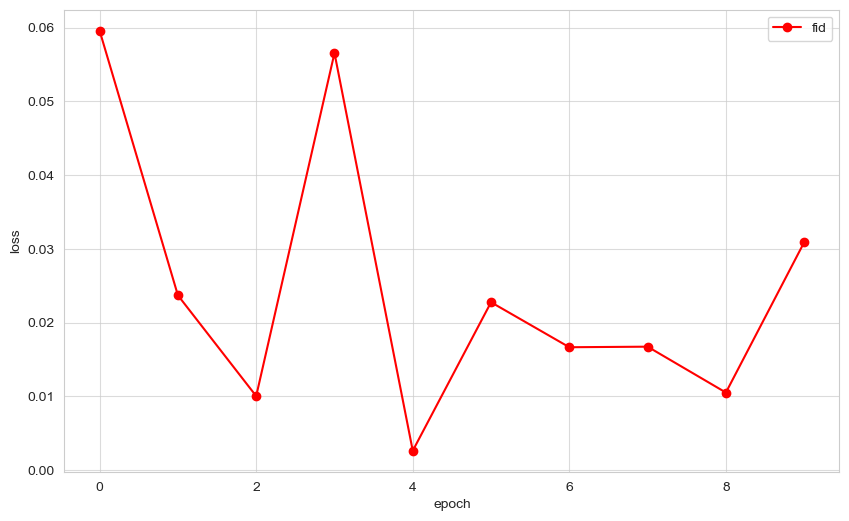

In [36]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(fid_scores, label='fid', marker='o', color='r')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.grid(True, linestyle='-', alpha=0.7)
plt.legend()
plt.show()

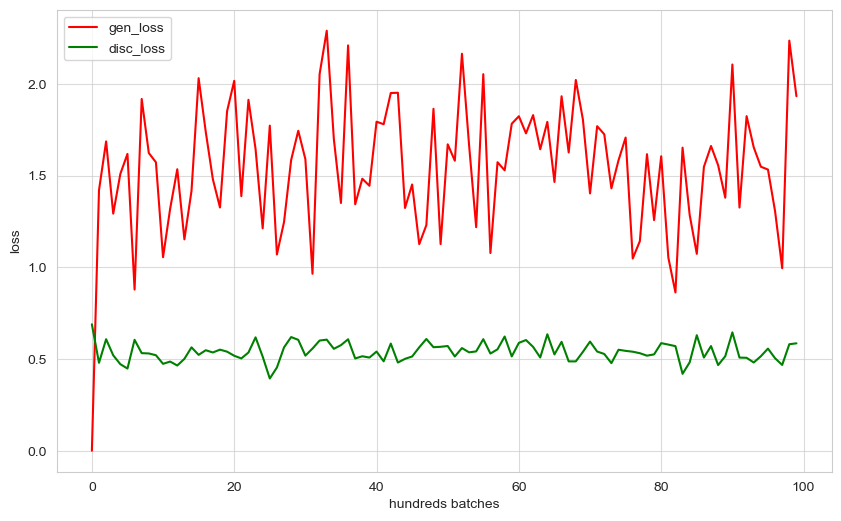

In [37]:
plt.figure(figsize=(10, 6))
plt.plot(gen_losses, label='gen_loss', color='r')
plt.plot(disc_losses, label='disc_loss', color='g')
plt.xlabel("hundreds batches")
plt.ylabel("loss")
plt.grid(True, linestyle='-', alpha=0.7)
plt.legend()
plt.show()

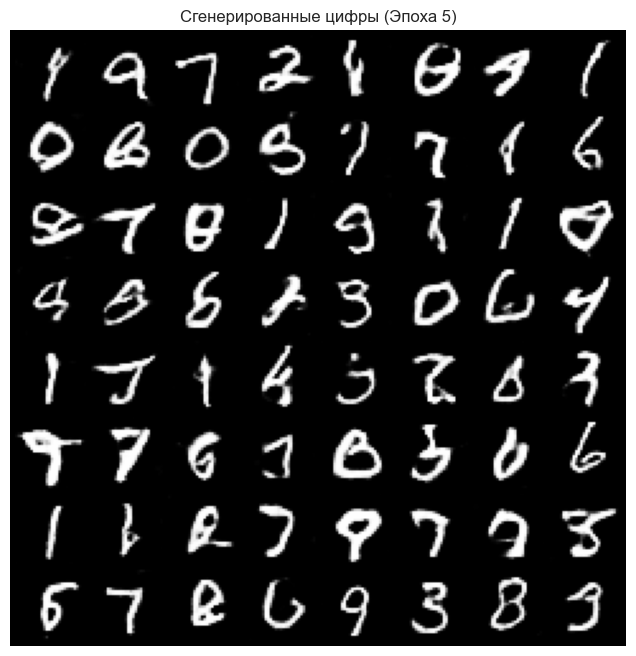

In [38]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

gen.eval()

with torch.no_grad():
    test_noise = torch.randn(64, 100, 1, 1).to(device)

    generated_images = gen(test_noise)

    generated_images = generated_images

    generated_images = (generated_images + 1) / 2

    grid = vutils.make_grid(generated_images, nrow=8, padding=2, normalize=False)

    plt.figure(figsize=(8, 8))
    plt.axis("off")
    plt.title("Сгенерированные цифры (Эпоха 5)")
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.show()

In [39]:
class Self_Attn(nn.Module):
    """ Self attention Layer"""
    def __init__(self, in_dim):
        super(Self_Attn,self).__init__()
        self.chanel_in = in_dim

        # Три свертки для создания Query, Key и Value (как в Трансформере!)
        # Сжимаем количество каналов в 8 раз для вычислений (чтобы экономить память)
        self.query_conv = nn.Conv2d(in_channels = in_dim , out_channels = in_dim//8 , kernel_size= 1)
        self.key_conv = nn.Conv2d(in_channels = in_dim , out_channels = in_dim//8 , kernel_size= 1)
        self.value_conv = nn.Conv2d(in_channels = in_dim , out_channels = in_dim , kernel_size= 1)

        # Гамма - это обучаемый параметр. В начале он равен 0 (внимание выключено).
        # По мере обучения сеть сама решает, насколько сильно использовать Attention.
        self.gamma = nn.Parameter(torch.zeros(1))
        self.softmax  = nn.Softmax(dim=-1)

    def forward(self,x):
        """
            inputs :
                x : input feature maps( B X C X W X H)
            returns :
                out : self attention value + input feature
        """
        m_batchsize, C, width ,height = x.size()

        # 1. Считаем Query и вытягиваем в длинную полосу
        proj_query  = self.query_conv(x).view(m_batchsize, -1, width*height).permute(0, 2, 1) # B X N X C
        # 2. Считаем Key и вытягиваем
        proj_key =  self.key_conv(x).view(m_batchsize, -1, width*height) # B X C x N
        # 3. Перемножаем Query и Key -> получаем карту внимания (Energy)
        energy =  torch.bmm(proj_query, proj_key)
        attention = self.softmax(energy) # B X N X N

        # 4. Применяем карту внимания к Value
        proj_value = self.value_conv(x).view(m_batchsize, -1, width*height) # B X C X N
        out = torch.bmm(proj_value, attention.permute(0, 2, 1))
        out = out.view(m_batchsize, C, width, height)

        # 5. Добавляем результат обратно к оригинальной картинке (Residual Connection),
        # умножая на гамму.
        out = self.gamma*out + x
        return out

In [40]:
class SAGenerator(nn.Module):
    def __init__(self, z_dim=100):
        super(SAGenerator, self).__init__()

        # Блок 1: Из шума (1x1) делаем (7x7)
        self.layer1 = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 256, kernel_size=7, stride=1, padding=0),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        # Блок 2: Из (7x7) делаем (14x14)
        self.layer2 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )

        # === ВСТАВЛЯЕМ ВНИМАНИЕ СЮДА ===
        # На входе 128 каналов от предыдущего слоя
        self.attn = Self_Attn(128)

        # Блок 3: Финальный слой (14x14) -> (28x28)
        self.last_layer = nn.Sequential(
            nn.ConvTranspose2d(128, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.attn(out)     # Пропускаем через Attention!
        out = self.last_layer(out)
        return out

In [41]:
class SADiscriminator(nn.Module):
    def __init__(self):
        super(SADiscriminator, self).__init__()

        # Слой 1: (28x28) -> (14x14)
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )

        # Слой 2: (14x14) -> (7x7)
        self.layer2 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )

        # === ВСТАВЛЯЕМ ВНИМАНИЕ СЮДА ===
        # На входе 256 каналов
        self.attn = Self_Attn(256)

        # Слой 3: (7x7) -> (1x1)
        self.last_layer = nn.Sequential(
            nn.Conv2d(256, 1, kernel_size=7, stride=1, padding=0),
            nn.Sigmoid()
        )

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.attn(out)     # Пропускаем через Attention!
        out = self.last_layer(out)
        return out.view(-1, 1)

In [42]:
gen = SAGenerator().to(device)
disc = SADiscriminator().to(device)

criterion = nn.BCELoss()

lr = 0.0002
opt_gen = optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=lr, betas=(0.5, 0.999))

In [43]:
epochs = 10
batch_size = 64

gen.train()
disc.train()

loss_gen = torch.tensor(0.0)

fid_scores = []
gen_losses = []
disc_losses = []

for epoch in range(epochs):
    # Теперь мы идем по реальному датасету!
    for batch_idx, (real_images, _) in enumerate(dataloader):

        # 1. Сплющиваем картинки и ОТПРАВЛЯЕМ НА DEVICE
        real_images = real_images.to(device)

        # --- ОБУЧЕНИЕ ДИСКРИМИНАТОРА ---
        disc_real_output = disc(real_images)

        # Сглаживание меток (Label Smoothing) - возвращаем наш трюк с 0.9!
        labels_real = (torch.ones_like(disc_real_output) * 0.9).to(device)
        loss_disc_real = criterion(disc_real_output, labels_real)

        # Шум тоже на device
        noise = torch.randn(real_images.size(0), 100, 1, 1).to(device)
        fake_images = gen(noise)
        disc_fake_output = disc(fake_images.detach())

        labels_fake = torch.zeros_like(disc_fake_output).to(device)
        loss_disc_fake = criterion(disc_fake_output, labels_fake)

        loss_disc = (loss_disc_fake + loss_disc_real) / 2
        opt_disc.zero_grad()
        loss_disc.backward()
        opt_disc.step()

        # --- ОБУЧЕНИЕ ГЕНЕРАТОРА ---
        if batch_idx % 100 != 0:
            output = disc(fake_images)
            labels_gen = torch.ones_like(output).to(device) # Метки на device
            loss_gen = criterion(output, labels_gen)

            opt_gen.zero_grad()
            loss_gen.backward()
            opt_gen.step()

        # --- ЛОГИРОВАНИЕ ---
        if batch_idx % 100 == 0:
            gen_losses.append(loss_gen.item())
            disc_losses.append(loss_disc.item())
            print(f"Эпоха [{epoch}/{epochs}] | Батч [{batch_idx}/{len(dataloader)}] | Loss D: {loss_disc.item():.4f} | Loss G: {loss_gen.item():.4f}")

    gen.eval()

    with torch.no_grad():
        # 2. Генерируем 64 фейковые картинки
        test_noise = torch.randn(64, 100, 1, 1).to(device)
        fake_images_fid = gen(test_noise)

        # 3. В качестве real_images мы просто берем переменную real_images,
        # которая осталась от последнего шага внутреннего цикла (там как раз лежат реальные цифры)

        # 4. Считаем FID
        fid_score = calculate_fid(real_images, fake_images_fid)
        fid_scores.append(fid_score)
        print(f"--- Эпоха [{epoch}/{epochs}] завершена | FID Score: {fid_score:.2f} ---")

    # 5. Возвращаем генератор в режим обучения для следующей эпохи!
    gen.train()

Эпоха [0/10] | Батч [0/938] | Loss D: 0.7331 | Loss G: 0.0000
Эпоха [0/10] | Батч [100/938] | Loss D: 0.1669 | Loss G: 6.3389
Эпоха [0/10] | Батч [200/938] | Loss D: 0.1666 | Loss G: 7.0145
Эпоха [0/10] | Батч [300/938] | Loss D: 0.1693 | Loss G: 7.7009
Эпоха [0/10] | Батч [400/938] | Loss D: 0.2826 | Loss G: 3.8696
Эпоха [0/10] | Батч [500/938] | Loss D: 0.4814 | Loss G: 2.6294
Эпоха [0/10] | Батч [600/938] | Loss D: 0.5013 | Loss G: 1.6565
Эпоха [0/10] | Батч [700/938] | Loss D: 0.4693 | Loss G: 1.4626
Эпоха [0/10] | Батч [800/938] | Loss D: 0.4533 | Loss G: 1.6490
Эпоха [0/10] | Батч [900/938] | Loss D: 0.5272 | Loss G: 1.7215
--- Эпоха [0/10] завершена | FID Score: 0.17 ---
Эпоха [1/10] | Батч [0/938] | Loss D: 0.5599 | Loss G: 1.3705
Эпоха [1/10] | Батч [100/938] | Loss D: 0.4752 | Loss G: 1.7542
Эпоха [1/10] | Батч [200/938] | Loss D: 0.5036 | Loss G: 1.5635
Эпоха [1/10] | Батч [300/938] | Loss D: 0.5220 | Loss G: 1.4697
Эпоха [1/10] | Батч [400/938] | Loss D: 0.5151 | Loss G: 1.

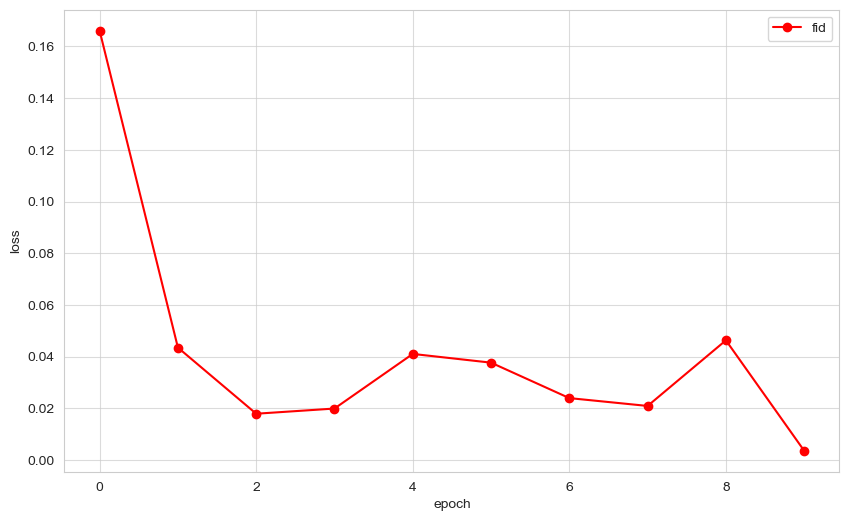

In [44]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(fid_scores, label='fid', marker='o', color='r')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.grid(True, linestyle='-', alpha=0.7)
plt.legend()
plt.show()

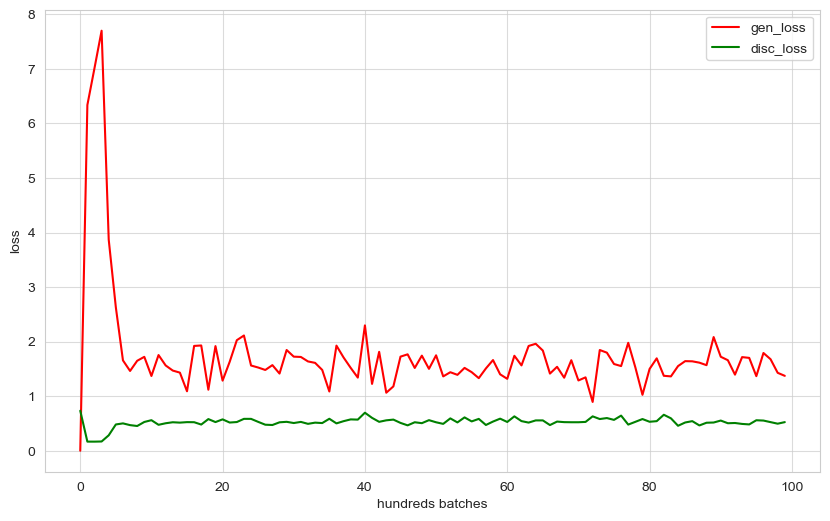

In [45]:
plt.figure(figsize=(10, 6))
plt.plot(gen_losses, label='gen_loss', color='r')
plt.plot(disc_losses, label='disc_loss', color='g')
plt.xlabel("hundreds batches")
plt.ylabel("loss")
plt.grid(True, linestyle='-', alpha=0.7)
plt.legend()
plt.show()

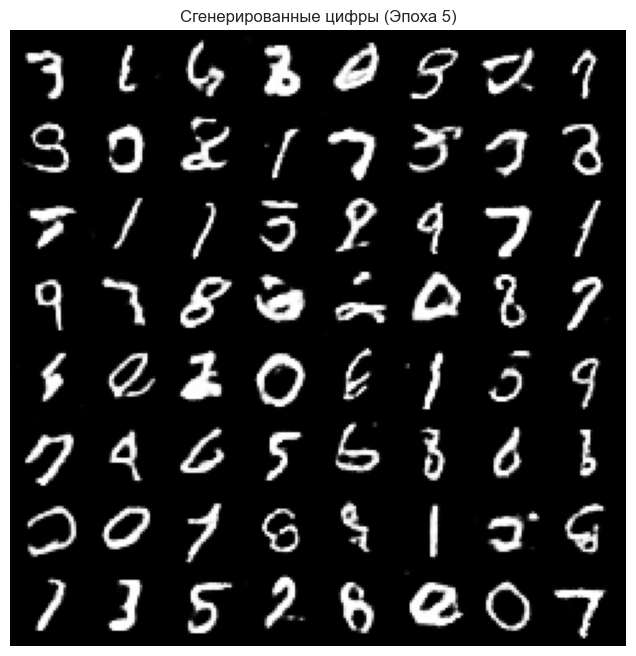

In [46]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

gen.eval()

with torch.no_grad():
    test_noise = torch.randn(64, 100, 1, 1).to(device)

    generated_images = gen(test_noise)

    generated_images = generated_images

    generated_images = (generated_images + 1) / 2

    grid = vutils.make_grid(generated_images, nrow=8, padding=2, normalize=False)

    plt.figure(figsize=(8, 8))
    plt.axis("off")
    plt.title("Сгенерированные цифры (Эпоха 5)")
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.show()